In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hmmlearn import hmm
import pyreadr

In [2]:
base_dir = "./gold_price_usd.csv"

In [3]:
data = pd.read_csv(base_dir)

In [4]:
data

,datetime,gold_price_usd
0,1978-12-29,137.06
1,1979-01-01,137.06
2,1979-01-02,137.29
3,1979-01-03,134.01
4,1979-01-04,136.79
...,...,...
11146,2021-09-20,1499.15
11147,2021-09-21,1513.45
11148,2021-09-22,1511.40
11149,2021-09-23,1489.43


In [5]:
data["datetime"] = pd.to_datetime(data["datetime"])

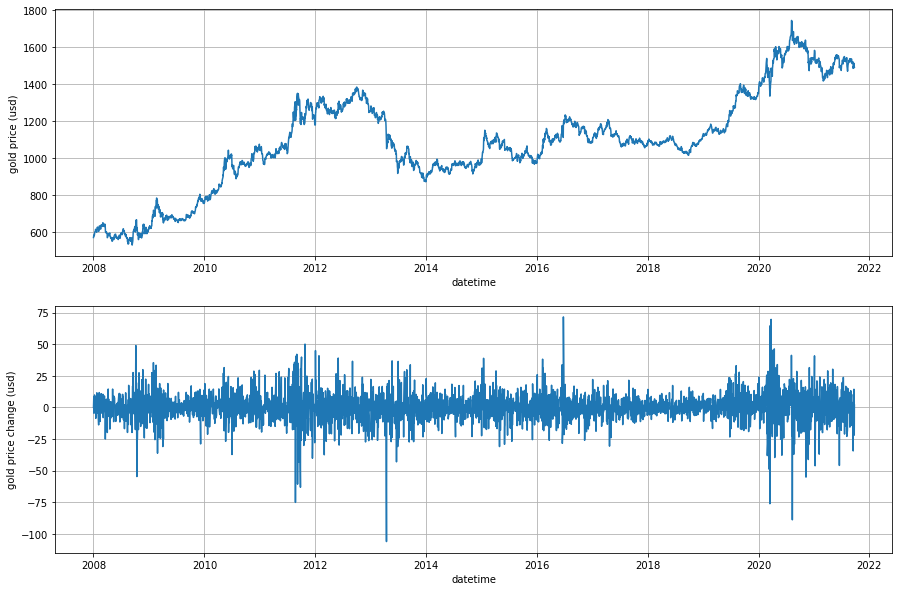

In [6]:
# get the difference from last row 
data["gold_price_change"] = data["gold_price_usd"].diff()

# Determine the daily change in gold price.
data["gold_price_change"] = data["gold_price_usd"].diff()

# Restrict the data to later than 2008 Jan 01.
data = data[data["datetime"] >= pd.to_datetime("2008-01-01")]

# Plot the daily gold prices as well as the daily change.
plt.figure(figsize = (15, 10))
plt.subplot(2,1,1)
plt.plot(data["datetime"], data["gold_price_usd"])
plt.xlabel("datetime")
plt.ylabel("gold price (usd)")
plt.grid(True)
plt.subplot(2,1,2)
plt.plot(data["datetime"], data["gold_price_change"])
plt.xlabel("datetime")
plt.ylabel("gold price change (usd)")
plt.grid(True)
plt.show()

In [7]:
# Use the daily change in gold price as the observed measurements X.
X = data[["gold_price_change", "gold_price_usd"]].values
# Build the HMM model and fit to the gold price change data.
model = hmm.GaussianHMM(n_components = 3, covariance_type = "diag", n_iter = 50, random_state = 42)
model.fit(X)
# Predict the hidden states corresponding to observed X.
Z = model.predict(X)
states = pd.unique(Z)

In [8]:
data[["gold_price_change", "gold_price_usd"]]

,gold_price_change,gold_price_usd
7567,0.00,570.26
7568,4.76,575.02
7569,8.34,583.36
7570,-4.66,578.70
7571,5.13,583.83
...,...,...
11146,3.07,1499.15
11147,14.30,1513.45
11148,-2.05,1511.40
11149,-21.97,1489.43


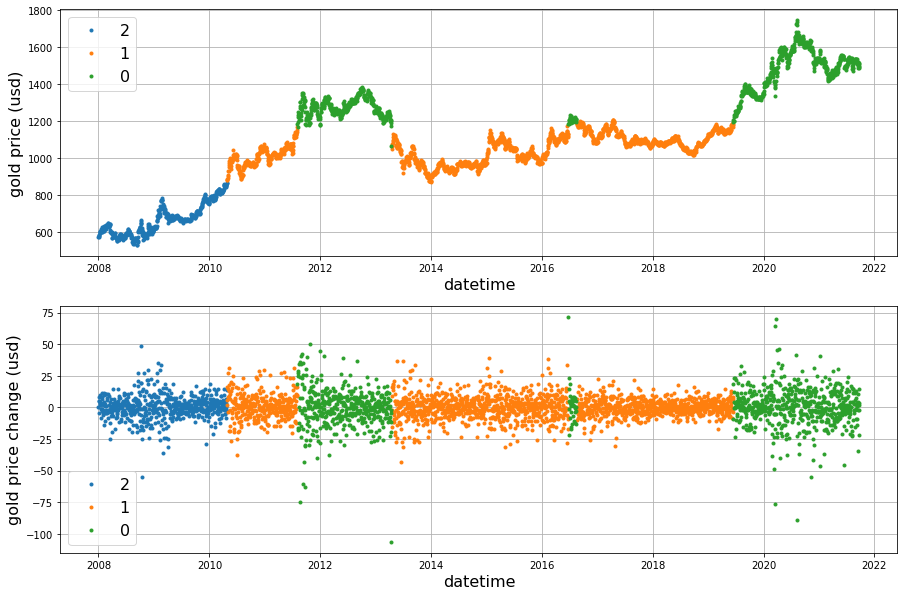

In [9]:
plt.figure(figsize = (15, 10))
plt.subplot(2,1,1)
for i in states:
    want = (Z == i)
    x = data["datetime"].iloc[want]
    y = data["gold_price_usd"].iloc[want]
    plt.plot(x, y, '.')
plt.legend(states, fontsize=16)
plt.grid(True)
plt.xlabel("datetime", fontsize=16)
plt.ylabel("gold price (usd)", fontsize=16)
plt.subplot(2,1,2)
for i in states:
    want = (Z == i)
    x = data["datetime"].iloc[want]
    y = data["gold_price_change"].iloc[want]
    plt.plot(x, y, '.')
plt.legend(states, fontsize=16)
plt.grid(True)
plt.xlabel("datetime", fontsize=16)
plt.ylabel("gold price change (usd)", fontsize=16)
plt.show()

In [112]:
Quare_high_result = pyreadr.read_r("/Users/rainlam/Project/3.SV/localPCA/male_guppy_genome/MDS/Quare.LG7.win100.lostruct.windows.rds")
Quare_high_result.values()

odict_values([           chrom       start         end     n         mid     mds01   
0     LR880651.1       208.0      7225.0     1      3716.5  0.293536  \
1     LR880651.1      7230.0     16594.0     2     11912.0  0.409154   
2     LR880651.1     16651.0     27621.0     3     22136.0  0.402410   
3     LR880651.1     27653.0     41050.0     4     34351.5  0.443697   
4     LR880651.1     41054.0     57321.0     5     49187.5  0.365289   
...          ...         ...         ...   ...         ...       ...   
4519  LR880651.1  33227967.0  33231630.0  4523  33229798.5 -0.398385   
4520  LR880651.1  33231635.0  33236424.0  4524  33234029.5 -0.309308   
4521  LR880651.1  33236449.0  33241295.0  4525  33238872.0 -0.251259   
4522  LR880651.1  33241296.0  33243293.0  4526  33242294.5 -0.139134   
4523  LR880651.1  33243298.0  33246520.0  4527  33244909.0 -0.212765   

         mds02     mds03     mds04     mds05  ...     mds31     mds32   
0     0.513228  0.195035  0.082498 -0.121562  ..

In [113]:
for k,v in Quare_high_result.items():
    df = v

In [114]:
subset_df = df.iloc[:,5:]
# data["gold_price_change"] = data["gold_price_usd"].diff()
df["mds02_diff"] = df["mds02"].diff()
df["mds01_diff"] = df["mds01"].diff()
df2= df[1:]

In [115]:
df[1:]

,chrom,start,end,n,mid,mds01,mds02,mds03,mds04,mds05,...,mds33,mds34,mds35,mds36,mds37,mds38,mds39,mds40,mds02_diff,mds01_diff
1,LR880651.1,7230.0,16594.0,2,11912.0,0.409154,0.667027,0.188620,0.025566,-0.118009,...,-0.004418,0.032241,-0.022495,0.027984,-0.012005,0.007774,0.007104,0.042834,0.153798,0.115618
2,LR880651.1,16651.0,27621.0,3,22136.0,0.402410,0.609215,0.204881,0.024156,-0.101936,...,-0.005951,0.041013,-0.045230,0.011738,-0.023927,0.028000,-0.018329,0.040595,-0.057812,-0.006744
3,LR880651.1,27653.0,41050.0,4,34351.5,0.443697,0.661661,0.191564,0.022328,-0.113298,...,0.003599,0.055909,-0.066585,0.017082,-0.029279,0.026475,-0.032930,0.036299,0.052446,0.041287
4,LR880651.1,41054.0,57321.0,5,49187.5,0.365289,0.622494,0.199761,0.039830,-0.119299,...,0.006794,0.021355,-0.051441,0.038357,-0.022215,0.010431,-0.021215,0.033421,-0.039167,-0.078408
5,LR880651.1,57488.0,70648.0,6,64068.0,0.323442,0.461078,0.177723,0.031690,-0.106302,...,-0.020263,0.021705,-0.025183,0.020755,-0.010012,0.021309,-0.040747,0.064478,-0.161417,-0.041847
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4519,LR880651.1,33227967.0,33231630.0,4523,33229798.5,-0.398385,0.050253,0.112354,-0.034640,0.003665,...,0.005756,-0.003245,0.002193,-0.005103,0.001125,-0.004933,-0.005340,0.013397,0.002654,-0.144925
4520,LR880651.1,33231635.0,33236424.0,4524,33234029.5,-0.309308,0.045085,-0.000514,-0.060026,0.028599,...,0.012256,-0.008108,-0.015486,-0.013354,0.017688,0.011897,-0.001398,-0.000462,-0.005167,0.089077
4521,LR880651.1,33236449.0,33241295.0,4525,33238872.0,-0.251259,0.005538,-0.080971,0.070467,0.129874,...,0.005659,0.026792,-0.035310,-0.024127,0.010289,0.042022,-0.029193,-0.033353,-0.039548,0.058049
4522,LR880651.1,33241296.0,33243293.0,4526,33242294.5,-0.139134,-0.040421,0.162984,-0.071671,0.114745,...,0.025876,-0.023038,-0.035267,-0.016908,-0.000520,-0.022607,0.002193,-0.010486,-0.045958,0.112125


In [147]:
# Use the daily change in gold price as the observed measurements X.
X = df2.iloc[:, 5:].values
# Build the HMM model and fit to the gold price change data.
model = hmm.GaussianHMM(n_components = 3, covariance_type = "diag", n_iter = 50, random_state = 42)
model.fit(X)
# Predict the hidden states corresponding to observed X.
Z = model.predict(X)
states = pd.unique(Z)

In [148]:
df2.iloc[:, 5:]

,mds01,mds02,mds03,mds04,mds05,mds06,mds07,mds08,mds09,mds10,...,mds33,mds34,mds35,mds36,mds37,mds38,mds39,mds40,mds02_diff,mds01_diff
1,0.409154,0.667027,0.188620,0.025566,-0.118009,0.120593,-0.099625,0.130561,0.087145,-0.096404,...,-0.004418,0.032241,-0.022495,0.027984,-0.012005,0.007774,0.007104,0.042834,0.153798,0.115618
2,0.402410,0.609215,0.204881,0.024156,-0.101936,0.134399,-0.108052,0.124761,0.109702,-0.083966,...,-0.005951,0.041013,-0.045230,0.011738,-0.023927,0.028000,-0.018329,0.040595,-0.057812,-0.006744
3,0.443697,0.661661,0.191564,0.022328,-0.113298,0.136977,-0.108338,0.138068,0.100716,-0.090500,...,0.003599,0.055909,-0.066585,0.017082,-0.029279,0.026475,-0.032930,0.036299,0.052446,0.041287
4,0.365289,0.622494,0.199761,0.039830,-0.119299,0.124735,-0.095318,0.142280,0.085959,-0.082255,...,0.006794,0.021355,-0.051441,0.038357,-0.022215,0.010431,-0.021215,0.033421,-0.039167,-0.078408
5,0.323442,0.461078,0.177723,0.031690,-0.106302,0.130203,-0.061619,0.103258,0.049734,-0.069551,...,-0.020263,0.021705,-0.025183,0.020755,-0.010012,0.021309,-0.040747,0.064478,-0.161417,-0.041847
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4519,-0.398385,0.050253,0.112354,-0.034640,0.003665,0.006600,0.023410,-0.058409,-0.002083,0.081047,...,0.005756,-0.003245,0.002193,-0.005103,0.001125,-0.004933,-0.005340,0.013397,0.002654,-0.144925
4520,-0.309308,0.045085,-0.000514,-0.060026,0.028599,0.060041,0.081955,-0.043531,-0.056710,-0.063990,...,0.012256,-0.008108,-0.015486,-0.013354,0.017688,0.011897,-0.001398,-0.000462,-0.005167,0.089077
4521,-0.251259,0.005538,-0.080971,0.070467,0.129874,0.005770,0.136898,-0.006851,-0.062351,-0.208334,...,0.005659,0.026792,-0.035310,-0.024127,0.010289,0.042022,-0.029193,-0.033353,-0.039548,0.058049
4522,-0.139134,-0.040421,0.162984,-0.071671,0.114745,0.091033,0.158401,-0.015643,-0.030765,-0.134244,...,0.025876,-0.023038,-0.035267,-0.016908,-0.000520,-0.022607,0.002193,-0.010486,-0.045958,0.112125


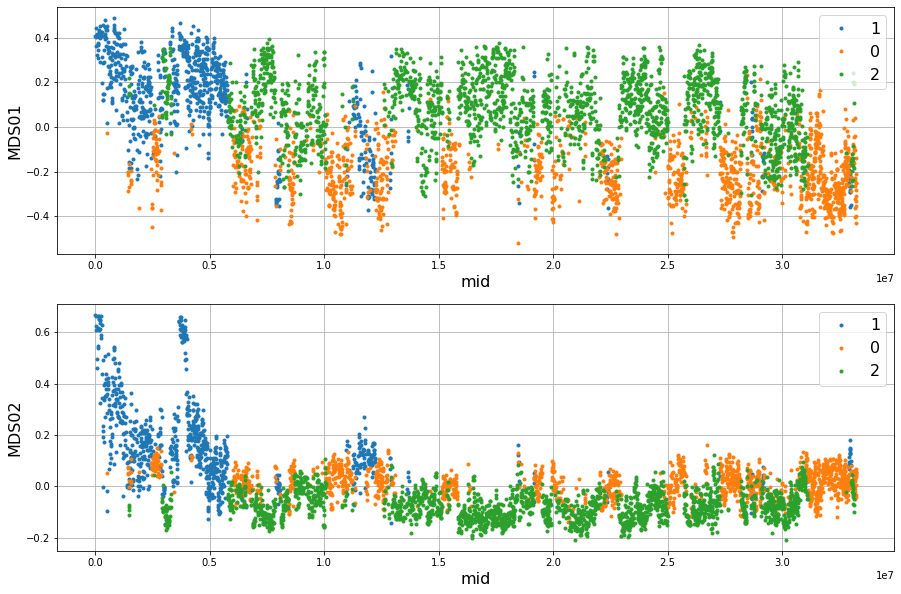

In [149]:
plt.figure(figsize = (15, 10))
plt.subplot(2,1,1)
for i in states:
    want = (Z == i)
    x = df2["mid"].iloc[want]
    y = df2["mds01"].iloc[want]
    plt.plot(x, y, '.')
plt.legend(states, fontsize=16)
plt.grid(True)
plt.xlabel("mid", fontsize=16)
plt.ylabel("MDS01", fontsize=16)
plt.subplot(2,1,2)
for i in states:
    want = (Z == i)
    x = df2["mid"].iloc[want]
    y = df2["mds02"].iloc[want]
    plt.plot(x, y, '.')
plt.legend(states, fontsize=16)
plt.grid(True)
plt.xlabel("mid", fontsize=16)
plt.ylabel("MDS02", fontsize=16)
plt.show()